# Treinamento com interface de alto nível

## Importação das bibliotecas

In [1]:
# http://pytorch.org/
from os.path import exists

import torch

In [13]:
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR
import pandas as pd
from torch.utils.data import Dataset

In [3]:
use_cuda = torch.cuda.is_available()
torch.manual_seed(1111)
device = torch.device("cuda" if use_cuda else "cpu")

##Preparação dos Dados




In [4]:
#!/bin/bash
!curl -L -o /content/student-exam-performance-prediction.zip\
  https://www.kaggle.com/api/v1/datasets/download/mrsimple07/student-exam-performance-prediction

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 19784  100 19784    0     0  23521      0 --:--:-- --:--:-- --:--:-- 23521


In [5]:
!unzip /content/student-exam-performance-prediction.zip

Archive:  /content/student-exam-performance-prediction.zip
  inflating: student_exam_data.csv   
  inflating: student_exam_data_new.csv  


In [7]:
df = pd.read_csv("/content/student_exam_data.csv")

In [8]:
df.head()

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Study Hours          500 non-null    float64
 1   Previous Exam Score  500 non-null    float64
 2   Pass/Fail            500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


In [10]:
X = df.iloc[:, :2].values
Y = df.iloc[:, 2].values

In [14]:
class SudentExamDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

X_scaler = StandardScaler()
X_train = X_scaler.fit_transform(X_train)
X_test = X_scaler.transform(X_test)

In [24]:
train_dataset = SudentExamDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
test_dataset = SudentExamDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))

In [25]:
train_kwargs = {'batch_size': 100}
test_kwargs = {'batch_size': 100}
if use_cuda:
    cuda_kwargs = {'num_workers': 1,
                    'pin_memory': True,
                    'shuffle': True}
    train_kwargs.update(cuda_kwargs)
    test_kwargs.update(cuda_kwargs)

train_loader = torch.utils.data.DataLoader(train_dataset,**train_kwargs)
test_loader = torch.utils.data.DataLoader(test_dataset, **test_kwargs)

## Criação da rede

In [42]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.input = nn.Linear(2, 128)
        self.drop1 = nn.Dropout(0.3)
        self.hidden = nn.Linear(128, 256)
        self.drop2 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):
        x = self.input(x)
        x = F.relu(x)
        x = self.drop1(x)
        x = self.hidden(x)
        x = F.relu(x)
        x = self.drop2(x)
        x = self.fc2(x)
        return x

model = Net()

In [43]:
model

Net(
  (input): Linear(in_features=2, out_features=128, bias=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (hidden): Linear(in_features=128, out_features=256, bias=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
)

## Treinamento

### Criando o objeto de treinamento

In [44]:
def train(model, device, train_loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100 * correct / len(train_loader.dataset)
    return train_loss, train_acc


In [45]:
def test(model, device, test_loader, criterion):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item() * data.size(0)
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    test_acc = 100. * correct / len(test_loader.dataset)

    return test_loss, test_acc

## Avaliação

In [46]:
epochs = 100
lr = 0.001
lr_decay = 10
patience = 10
patience_counter = 0
best_acc = 0

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

model = Net().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()
scheduler = StepLR(optimizer, step_size=lr_decay, gamma=0.5)

print("Iniciando Treinamento ...")

for epoch in range(1, epochs + 1):

  train_loss, train_acc = train(model, device, train_loader, optimizer, criterion)
  test_loss, test_acc = test(model, device, test_loader, criterion)
  scheduler.step()

  print(f"Época: {epoch} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

  history['train_loss'].append(train_loss)
  history['train_acc'].append(train_acc)
  history['test_loss'].append(test_loss)
  history['test_acc'].append(test_acc)

  if test_acc > best_acc:
    best_acc = test_acc
    print("Salvando melhor época ...")
    torch.save(model.state_dict(), "mnist_cnn.pt")
    patience_counter = 0
  else:
    patience_counter += 1
    if patience_counter == patience:
      print(f"Parando Treinamento por Patience na época {epoch}...")
      break

Iniciando Treinamento ...
Época: 1 | Train Loss: 0.5998, Train Acc: 72.29% | Test Loss: 0.4601, Test Acc: 82.67%
Salvando melhor época ...
Época: 2 | Train Loss: 0.4178, Train Acc: 85.71% | Test Loss: 0.3430, Test Acc: 90.00%
Salvando melhor época ...
Época: 3 | Train Loss: 0.3169, Train Acc: 90.57% | Test Loss: 0.2712, Test Acc: 91.33%
Salvando melhor época ...
Época: 4 | Train Loss: 0.2455, Train Acc: 91.71% | Test Loss: 0.2282, Test Acc: 92.67%
Salvando melhor época ...
Época: 5 | Train Loss: 0.1989, Train Acc: 92.57% | Test Loss: 0.2038, Test Acc: 92.67%
Época: 6 | Train Loss: 0.1714, Train Acc: 92.86% | Test Loss: 0.1905, Test Acc: 92.00%
Época: 7 | Train Loss: 0.1502, Train Acc: 92.86% | Test Loss: 0.1777, Test Acc: 92.67%
Época: 8 | Train Loss: 0.1353, Train Acc: 95.14% | Test Loss: 0.1643, Test Acc: 93.33%
Salvando melhor época ...
Época: 9 | Train Loss: 0.1177, Train Acc: 94.86% | Test Loss: 0.1520, Test Acc: 94.00%
Salvando melhor época ...
Época: 10 | Train Loss: 0.1079, Tra

## Visualização dos Resultados

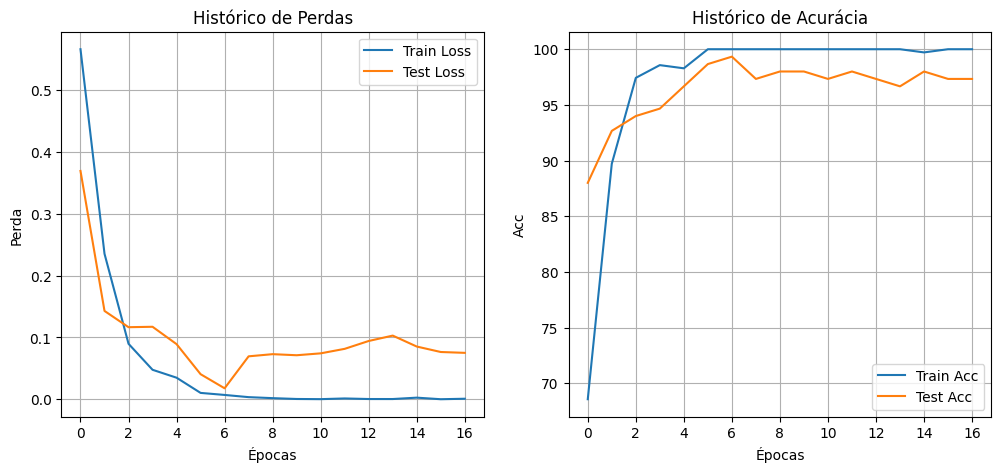

In [36]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 5))

#Perda
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.title('Histórico de Perdas')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.grid(True)

#Acurácia
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['test_acc'], label='Test Acc')
plt.title('Histórico de Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Acc')
plt.legend()
plt.grid(True)

plt.show()